In [1]:
import pandas as pd
import seaborn as sns
import pathlib as pl
import matplotlib.pyplot as plt

In [2]:
root_path = pl.Path.cwd().parent.parent
data_path = root_path / "data" / "intermed"

In [3]:
data = pd.read_csv(data_path/"googleplaystore_clean.csv")

<Axes: xlabel='Content Rating', ylabel='Installs'>

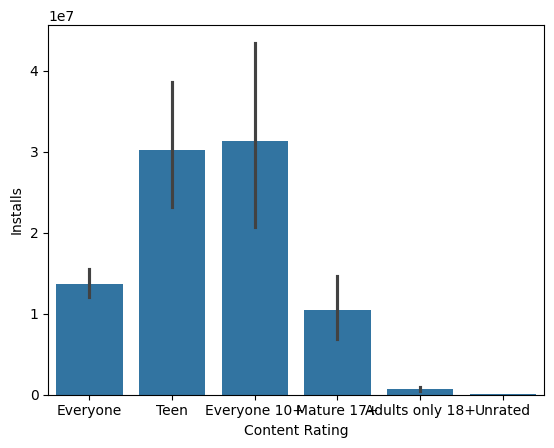

In [4]:
sns.barplot(data=data,x="Content Rating",y="Installs")


In [5]:
display(data.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10))

Category
GAME                  3.224896e+10
COMMUNICATION         2.415224e+10
FAMILY                1.278720e+10
SOCIAL                1.251384e+10
PRODUCTIVITY          1.246307e+10
TOOLS                 1.146072e+10
PHOTOGRAPHY           9.721243e+09
TRAVEL_AND_LOCAL      6.361959e+09
VIDEO_PLAYERS         6.236897e+09
NEWS_AND_MAGAZINES    5.393111e+09
Name: Installs, dtype: float64

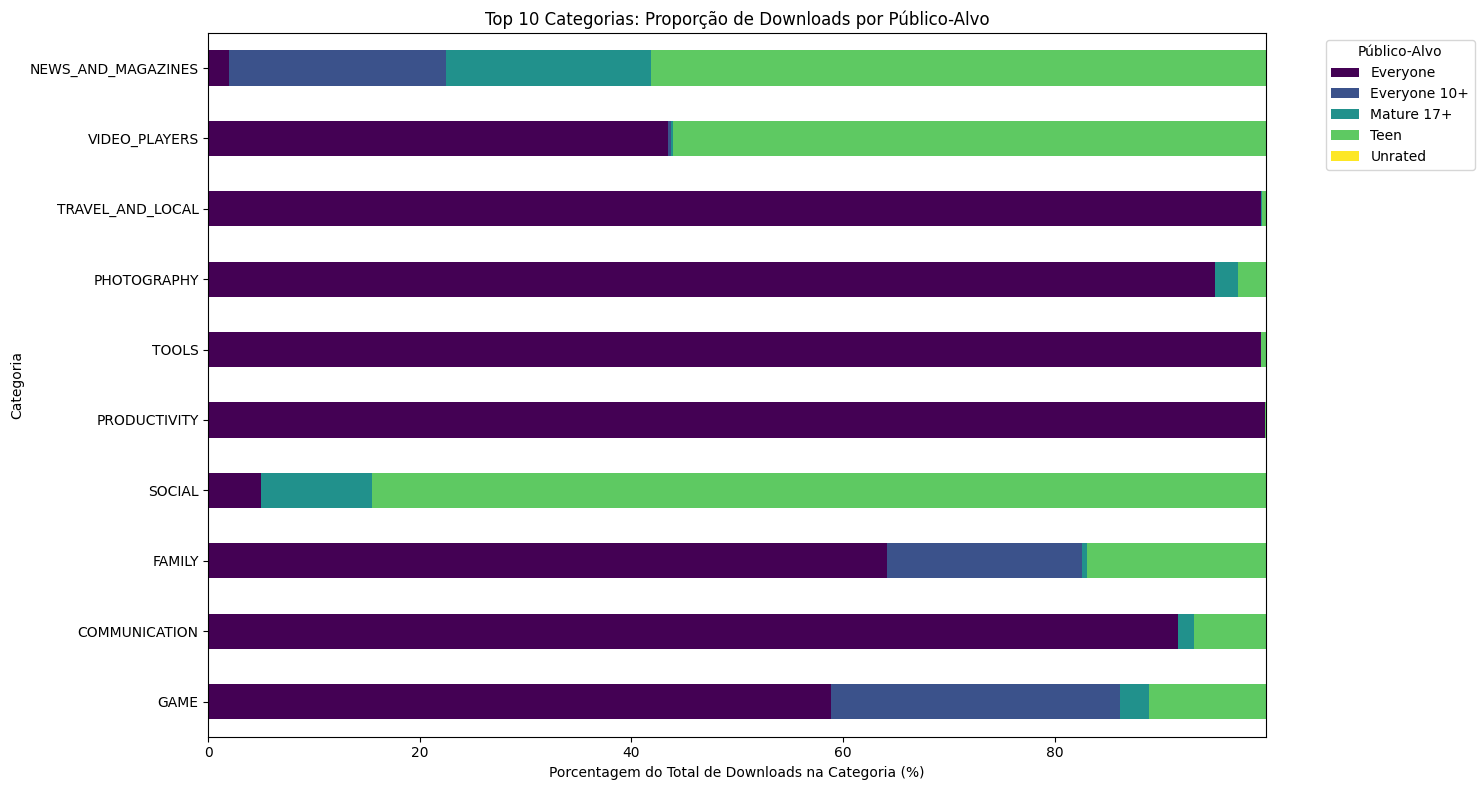

In [ ]:

data['Installs'] = data['Installs'].astype(str).str.replace(r'\W', '', regex=True).astype(float)

top_10_categories = data.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10).index

subset = data[data['Category'].isin(top_10_categories)]

pivot_df = subset.pivot_table(index='Category', 
                              columns='Content Rating', 
                              values='Installs', 
                              aggfunc='sum').fillna(0)

ct_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

ct_perc = ct_perc.loc[top_10_categories]

ct_perc.plot(kind='barh', stacked=True, figsize=(15, 8), colormap='viridis')

plt.title('Top 10 Categorias: Proporção de Downloads por Público-Alvo')
plt.xlabel('Porcentagem do Total de Downloads na Categoria (%)')
plt.ylabel('Categoria')
plt.legend(title='Público-Alvo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()